# Task 1: Design a Federated Learning Training Algorithm on the Breast Cancer Wisconsin Data Set Using the Flower Framework

**Objective:**
To assess your ability to design and implement a federated learning solution, simulate a decentralized training environment, and demonstrate your knowledge of basic federated learning concepts

**Task Description:**
- Implement a federated learning system using the Flower framework on the Breast Cancer Wisconsin dataset. The dataset will be split into multiple subsets (clients) that simulate data being held at different hospitals
- The system should train a simple machine learning model in a federated manner, where each client trains its local model on its subset of the data, and a central server aggregates the updates

**Steps:**
1. Data Distribution:
    - Split the Breast Cancer Wisconsin dataset into 3–5 clients, each representing a different hospital
2. Model Training:
    - Implement a machine learning model using a library of your choice
    - Set up the Flower framework to coordinate the training process across clients
3. Model Aggregation:
    - Implement an aggregation mechanism, where the central server aggregates the model updates from clients to produce a global model


# Import required modules

In [1]:
!pip install -q flwr[simulation] flwr-datasets[vision] torch torchvision matplotlib
!pip install ray


[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: python3 -m pip install --upgrade pip
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 MB 35.2 MB/s eta 0:00:00:00:0100:01

[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import os 

# Load our dataset
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from datasets.utils.logging import disable_progress_bar

import flwr
from flwr.client import ClientApp
from flwr.server import ServerApp
from flwr.simulation import run_simulation

import torch
import random
from IPython.display import display
 
from compose_setup.breastcancer.breastcancer import task
from compose_setup.breastcancer.breastcancer.server_app import server_fn
from compose_setup.breastcancer.breastcancer.client_app import client_fn
from compose_setup.breastcancer.breastcancer.task import CustomDataset, load_breast_cancer_datasets, SimpleNN, train, test

# Set seed for reproducibility
seed = 0
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)

DEVICE = torch.device("cpu")  # Try "cuda" to train on GPU
print(f"Training on {DEVICE}")
print(f"Flower {flwr.__version__} / PyTorch {torch.__version__}")
disable_progress_bar()

/home/codespace/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2024-10-29 13:19:55,292	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


Training on cpu
Flower 1.12.0 / PyTorch 2.5.0+cu124


# Load the breast cancer dataset

**Idea:** 
- identify irregularity in breast tissue through mammography
- perform fine needle aspiration (FNA) biopsy to obtain tissue sample
- analyse to diagnose the mass as cancerous or benign (based on cell nucleus properties)

![alt text](es1.jpg)

Reference with image: https://www.rxdatascience.com/blog/machine-learning-and-healthcare-breast-cancer-diagnosis-  
(Link with images from official dataset website does not work: http://www.cs.wisc.edu/~street/images/)

**Additional Variable Information on the measured cell nucleus properties:**

**1) ID number**

**2) Diagnosis (M = malignant, B = benign)**

**3-32) Ten real-valued features are computed for each cell nucleus:**

a) radius (mean of distances from center to points on the perimeter)

b) texture (standard deviation of gray-scale values)

c) perimeter

d) area

e) smoothness (local variation in radius lengths)

f) compactness (perimeter^2 / area - 1.0)

g) concavity (severity of concave portions of the contour)

h) concave points (number of concave portions of the contour)

i) symmetry 

j) fractal dimension ("coastline approximation" - 1

**For each of these features there are three columns to measure the:**
1. Mean: average value of feature across cells in sample
2. Standard Error (SE): standard error measures variability
3. Worst: worst value of feature across cells in sample

In [3]:
df = pd.read_csv("./breast-cancer-dataset/data.csv")
display(df)
display(df.describe())

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


Text(0.5, 1.0, 'Overview of disbalanced classes')

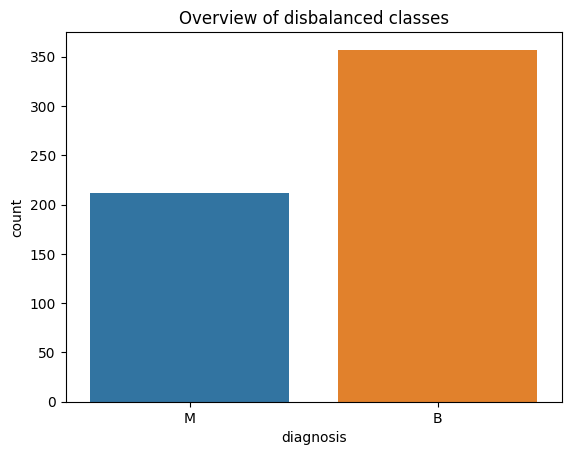

In [4]:
sns.countplot(x="diagnosis", data=df, hue="diagnosis");
plt.title("Overview of disbalanced classes")

We could perform oversampling (generating synthetic samples of the minority class) or undersampling (limiting samples of the majority class) to counteract this disbalance.

**Oversampling our minority class** "malignent" could be done with SMOTE (Synthetic Minority Over-sampling Technique): https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html 

**Undersampling our majority class** "benign" could be done with the RandomUnderSampler also from imblearn: https://imbalanced-learn.org/stable/references/generated/imblearn.under_sampling.RandomUnderSampler.html

To keep this notebook straight-forward, I leave out the implementation of sampling strategies & the performance comparisons.

## Brief overview and adjustment of data 

Each patient has a unique ID, a diagnosis indicating whether the breast cancer is benign or malignent and numerous other numerical features.

We don't want our model to consider the ID for the predicitions and drop the column.

Our target for the predictions is the diagnosis column, which we need to map to numerical values with B(benign) = 0 and M (malignent) = 1.

The column "Unnamed: 32" can be omitted, since it only contains "NaN" values.

The remaining numerical columns are used as features.

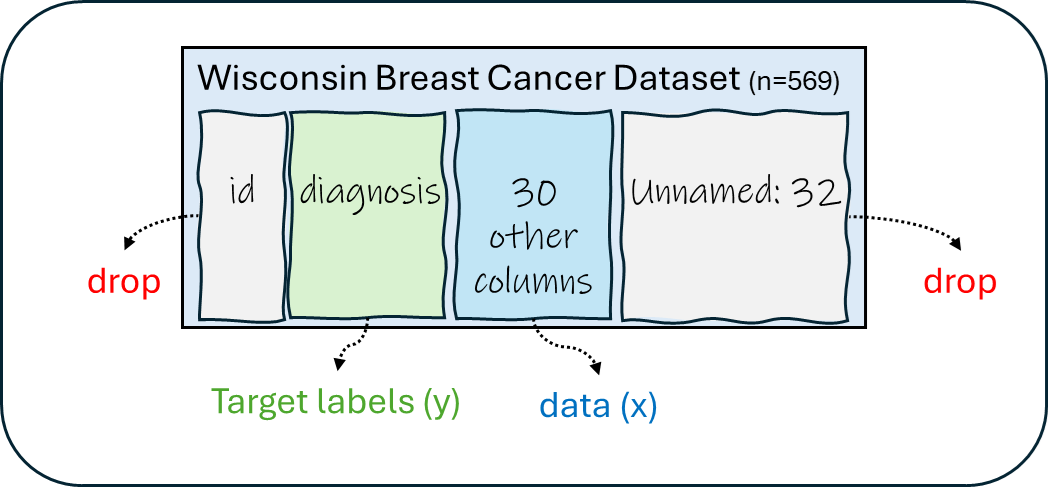

In [5]:
df["diagnosis"] = df["diagnosis"].map({"B":0,"M":1})
labels = df["diagnosis"]

df = df.drop(axis="columns",columns=["id","Unnamed: 32"],errors="ignore")
features = df.drop(axis="columns",columns=["diagnosis"])

**What features should be selected and what should be modified?**

Now typically the data cleaning & feature analysis would take place by inspecting distributions, correlations and in a medical context also plausiblity of values in the features.

**Severl key points to analyze and handle:**
1. Data quality: 
    - missing values (e.g. imputation)
    - inconsistencies (manually coded categorical data could have values not defined for column "1 or 2" instead of 1 or 2)
2. Feature engineering:
    - feature analysis: e.g. are features (column) strongly correlated? -> medical data such as bmi derived from height and weight is correlated and could be dropped
    - plausiblity check: compare present values of features with reference data (e.g. reference data sent from lab for devices or reference for cell nucleus parameters etc.) -> helps eliminate errors/reveal potential problems in data
3. Feature selection:
    - feature selection strategies: e.g. univariate feature selection (check correlation/impact of each feature individually with target "diagnosis")
4. Feature scaling: 
    - since the features can have very different value ranges, we should normalize them to ensure that models that consider for example distances can be used effectively
      -> for example a KNN would consider the distances of the patient vectors and then a feature like "age" with a value of 70 contributes much more to the distance than smaller values between 0 and 1

There are multiple in-depth approaches available so I skipped this part to focus on the flower implementation & docker compose orchestration:
https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data/code?datasetId=180&sortBy=voteCount

## What could a realistic use-case look like?

There could be 3-5 different institutions holding patient data.

We want to train a ML model on the data and also evaluate it.

The data could be split across the institutions in a horizontal or vertical way.

**Horizontal split** would mean each institution has the same type of data but for different patients, for example in the case of three university hospitals.

**Vertical split** would mean each institution has some different type of data for the same patients, for example when the patient visits each institution for different tests, such as a family doctor first, specialist second and then university hospital last, where the diagnosis is made.

In the following I will only test the first use-cases by splitting the data horizontally.

This is the more common use case and more prevalent in literature, although vertical federated learning is also relevant in a medical settings (e.g. patient journey through multiple institutions).

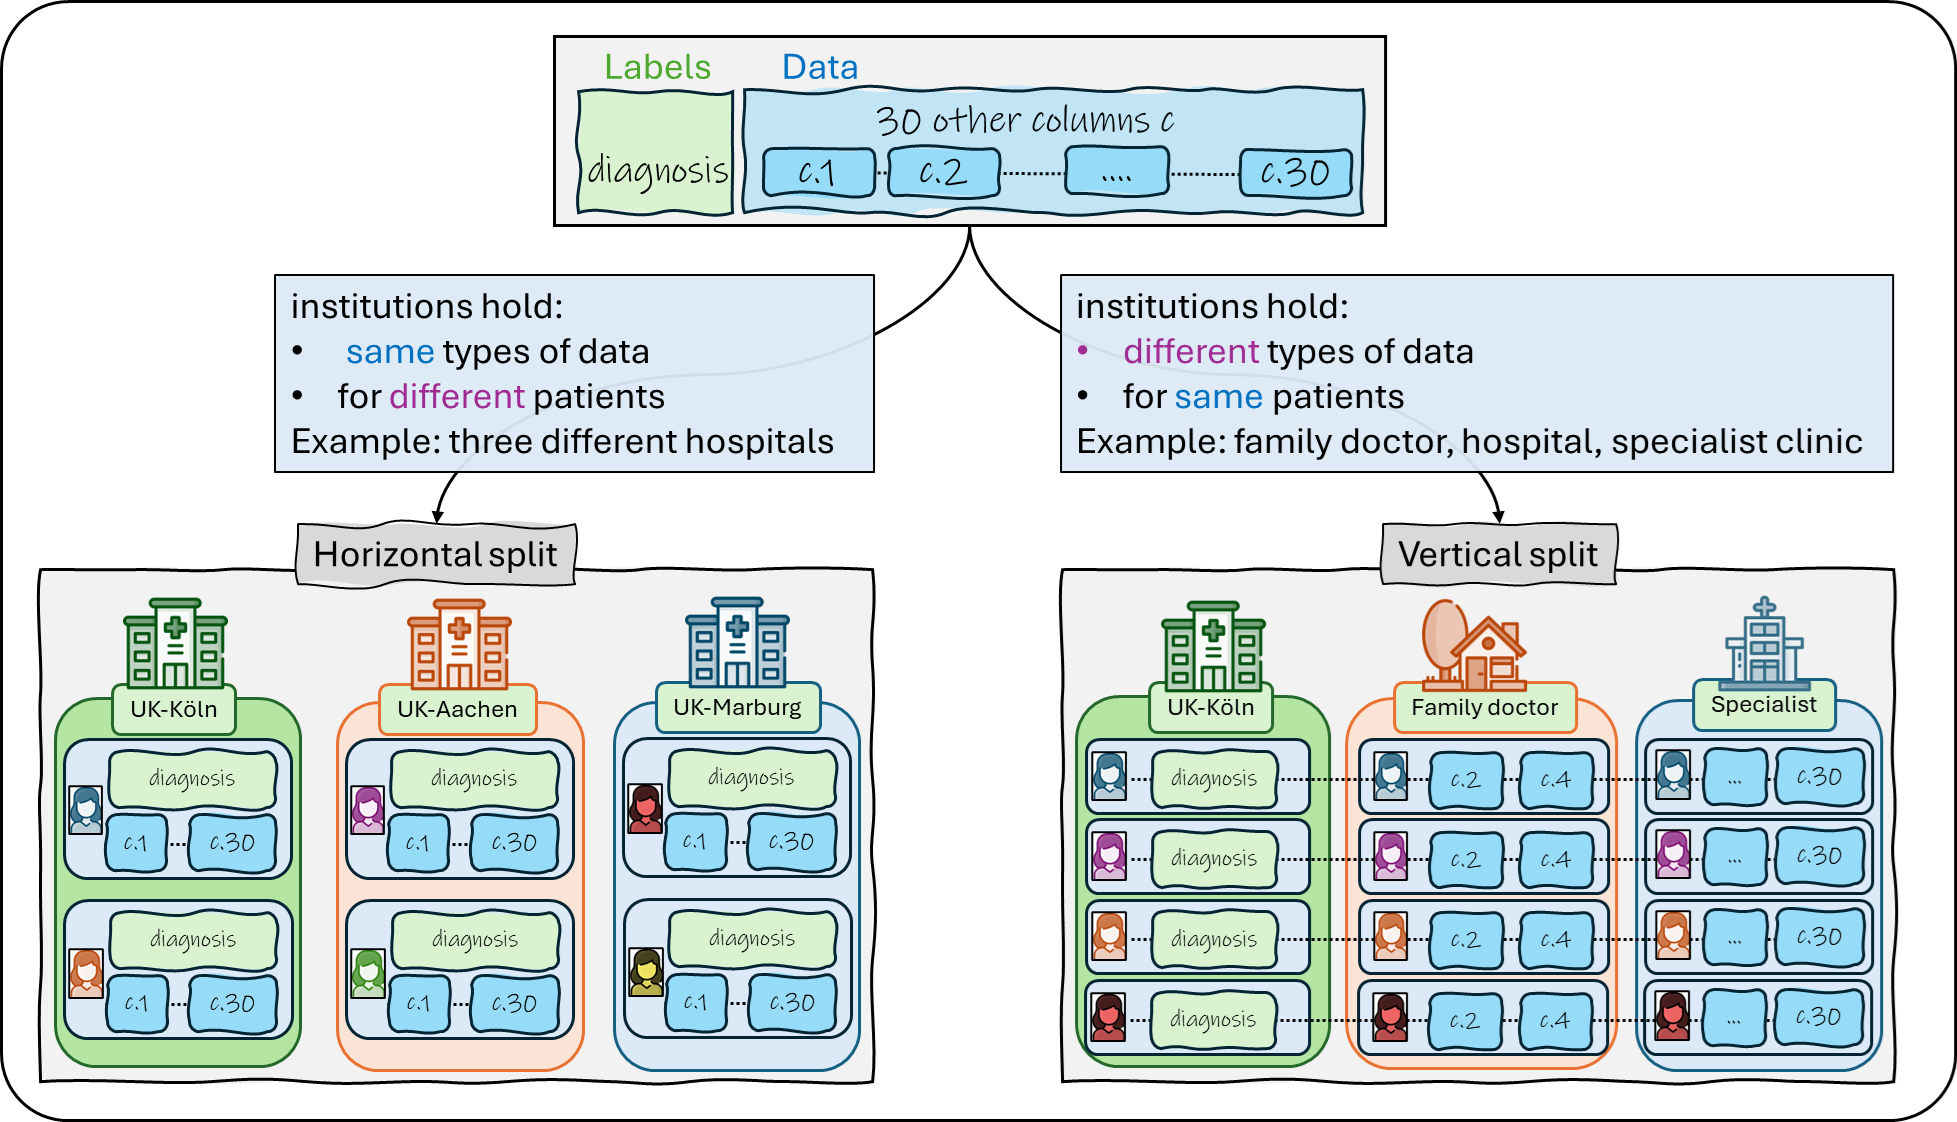

# Subtask 1. Data Distribution:
Split the Breast Cancer Wisconsin dataset into 3–5 clients, each representing a different hospital

The dataset of each client (partition) should consist of training and testing data for the evaluation.

**Plan:** 
- Split up entire dataset into 80% training and 20% testing dataset
- Divide the 80% training data to the clients and withhold the testing data for the final performance evaluation later
- Each client splits up the received data into 80% training and 20% testing 

--> 80-20 split chosen based on common practice but could also be any other split, like 70-30 etc.

**Simplified overview of data distribution for training & validation of models per institution and global performance evaluation (Centralized server-side evaluation):**
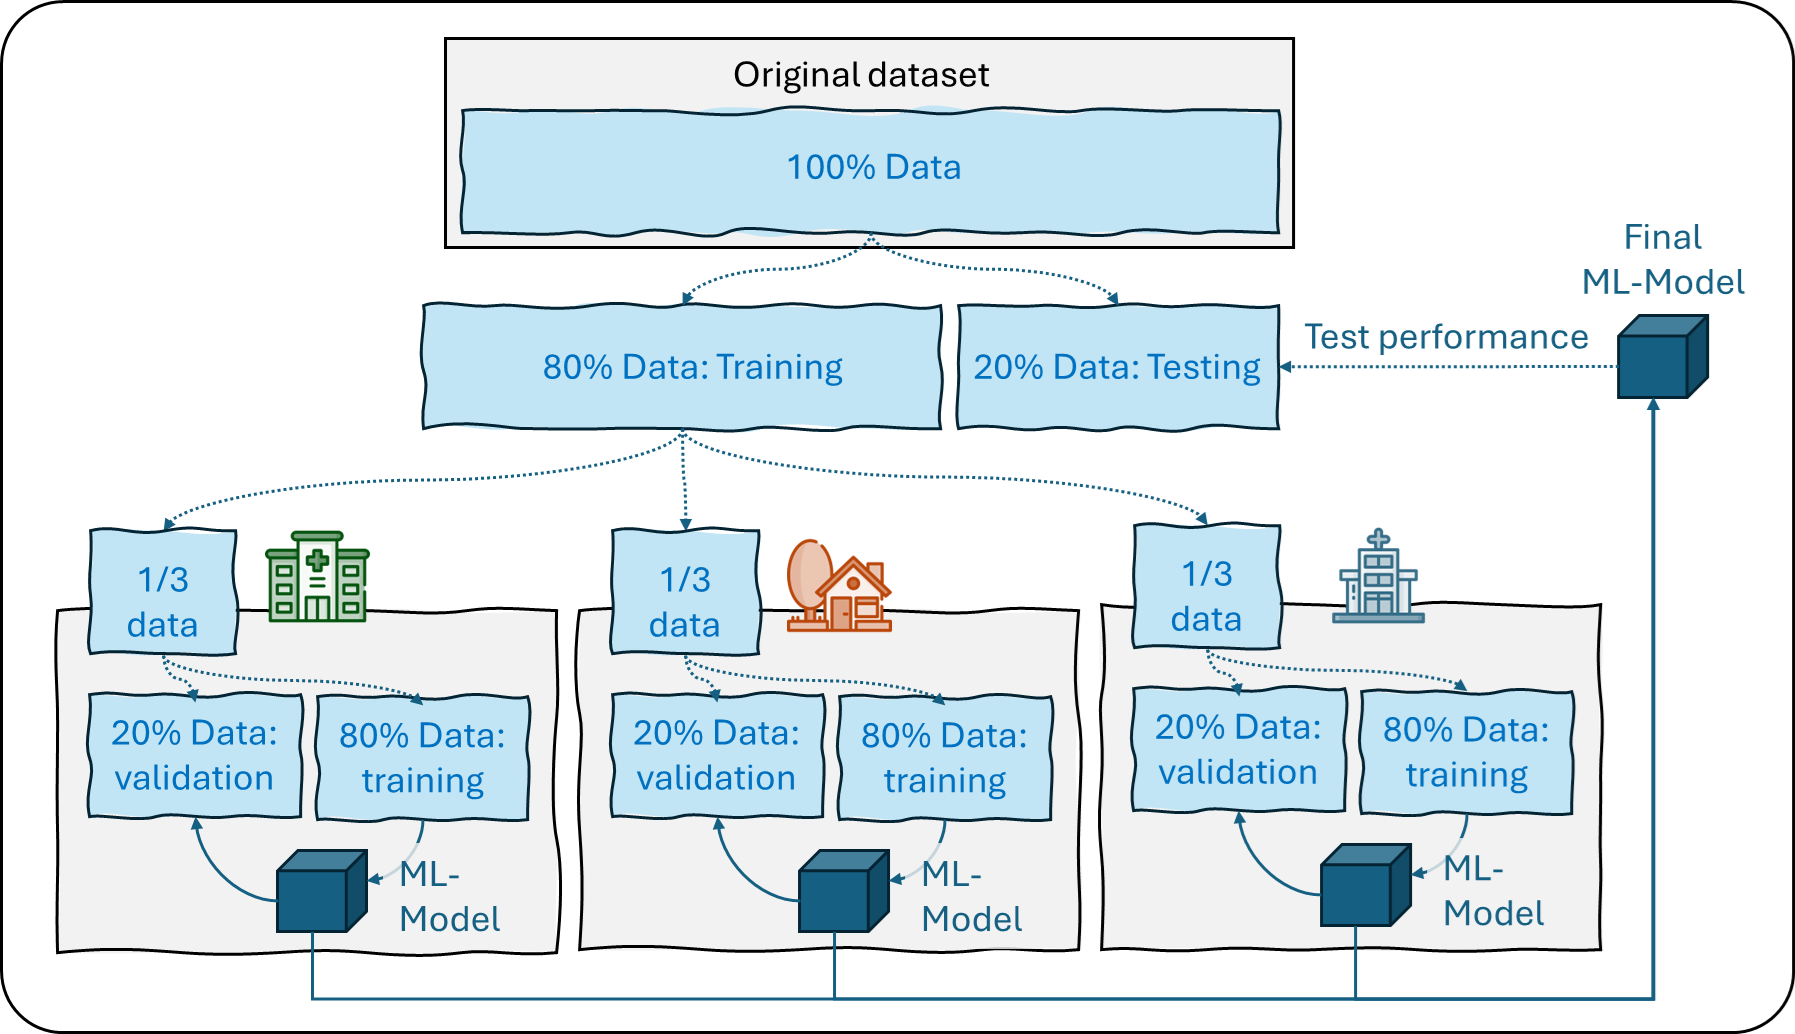

In [6]:
## Split original data into 80% training (for use by institutions) and 20% testing (withheld from institutions)

train_features, test_features, train_labels, test_labels = train_test_split(features, labels, test_size=0.2, random_state=seed)

test_data_path = "./compose_setup/breastcancer/test_data"
test_features.to_csv(f"{test_data_path}/test_features.csv",index=False)
test_labels.to_csv(f"{test_data_path}/test_labels.csv",index=False)

## Horizontal data split (#1 use case)

Splitting the data with the patients into subsets to simulate the institutions, where each subset contains all the data of different patients.

In [7]:
NUMBER_OF_INSTITUTIONS = 5

institution_data_path = "./institution_data/"
if(not os.path.exists(institution_data_path)):
    os.mkdir(institution_data_path)
max_data_size_per_institution = int(np.round(len(train_labels)/NUMBER_OF_INSTITUTIONS))
institution_labels = []
institution_data = []

for current_institution in range(NUMBER_OF_INSTITUTIONS):
    institution_labels.append(train_labels[current_institution*max_data_size_per_institution:(current_institution+1)*max_data_size_per_institution])
    institution_data.append(train_features[current_institution*max_data_size_per_institution:(current_institution+1)*max_data_size_per_institution])
    if not os.path.exists(institution_data_path):
        os.mkdir(institution_data_path)
    institution_data[current_institution].to_csv(f"{institution_data_path}/data_institution_{current_institution}.csv",index=False)
    institution_labels[current_institution].to_csv(f"{institution_data_path}/labels_institution_{current_institution}.csv",index=False)
    trainloader, valloader = load_breast_cancer_datasets(current_institution)

Loading breast cancer dataset
Loading breast cancer dataset
Loading breast cancer dataset
Loading breast cancer dataset
Loading breast cancer dataset


### Test model locally with 80% training data and 20% testing data

In [8]:
# Set seed for reproducibility
seed = 0
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)

BATCH_SIZE = 32

model = SimpleNN()
num_epochs = 10

train_dataset = CustomDataset(data=train_features, labels=train_labels)
test_dataset = CustomDataset(data=test_features, labels=test_labels)
trainloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valloader = DataLoader(test_dataset, batch_size=BATCH_SIZE,shuffle=False)

train(model, trainloader, num_epochs, verbose=True)

loss, accuracy = test(model, valloader)
print(f"Final test set performance:\n\tloss {loss:.4f}\n\taccuracy {accuracy:.2f}%")

Epoch 1: train loss 0.0659, accuracy 0.4264
Epoch 2: train loss 0.0231, accuracy 0.5648
Epoch 3: train loss 0.0151, accuracy 0.8264
Epoch 4: train loss 0.0131, accuracy 0.8923
Epoch 5: train loss 0.0122, accuracy 0.8725
Epoch 6: train loss 0.0106, accuracy 0.9033
Epoch 7: train loss 0.0098, accuracy 0.9011
Epoch 8: train loss 0.0089, accuracy 0.9121
Epoch 9: train loss 0.0084, accuracy 0.9187
Epoch 10: train loss 0.0083, accuracy 0.9187
correct: 108, total: 114
Final test set performance:
	loss 0.2621
	accuracy 94.74%


## Simulate training across the institutions

In [9]:
# Set seed for reproducibility
seed = 0
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)

# Specify the resources each of your clients need









# By default, each client will be allocated 1x CPU and 0x GPUs
backend_config = {"client_resources": {"num_cpus": 1, "num_gpus": 0.0}}

# When running on GPU, assign an entire GPU for each client
if DEVICE.type == "cuda":
    backend_config = {"client_resources": {"num_cpus": 1, "num_gpus": 1.0},"backend": "ray"}
    # Refer to our Flower framework documentation for more details about Flower simulations
    # and how to set up the `backend_config`

# Create the ClientApp
client = ClientApp(client_fn=client_fn)

# Create the ServerApp
server = ServerApp(server_fn=server_fn)

# Run simulation
run_simulation(
    server_app=server,
    client_app=client,
    num_supernodes=NUMBER_OF_INSTITUTIONS,
    backend_config=backend_config,
)

INFO :      Starting Flower ServerApp, config: num_rounds=10, no round_timeout
INFO :      
INFO :      [INIT]
INFO :      Using initial global parameters provided by strategy
INFO :      Starting evaluation of initial global parameters
INFO :      Evaluation returned no results (`None`)
INFO :      
INFO :      [ROUND 1]


INFO :      configure_fit: strategy sampled 5 clients (out of 5)
2024-10-29 13:20:11,894	WARNING services.py:2022 -- WARNING: The object store is using /tmp instead of /dev/shm because /dev/shm has only 67108864 bytes available. This will harm performance! You may be able to free up space by deleting files in /dev/shm. If you are inside a Docker container, you can increase /dev/shm size by passing '--shm-size=2.07gb' to 'docker run' (or add it to the run_options list in a Ray cluster config). Make sure to set this to more than 30% of available RAM.


(ClientAppActor pid=4348) Loading breast cancer dataset


INFO :      aggregate_fit: received 5 results and 0 failures
INFO :      configure_evaluate: strategy sampled 5 clients (out of 5)
INFO :      aggregate_evaluate: received 5 results and 0 failures
INFO :      
INFO :      [ROUND 2]
INFO :      configure_fit: strategy sampled 5 clients (out of 5)


Saving round 1 aggregated_ndarrays...
(ClientAppActor pid=4348) correct: 4, total: 19
(ClientAppActor pid=4348) correct: 6, total: 19
(ClientAppActor pid=4348) correct: 3, total: 19


...

Saving round 8 aggregated_ndarrays...


INFO :      aggregate_fit: received 5 results and 0 failures
INFO :      configure_evaluate: strategy sampled 5 clients (out of 5)
INFO :      aggregate_evaluate: received 5 results and 0 failures
INFO :      
INFO :      [ROUND 10]
INFO :      configure_fit: strategy sampled 5 clients (out of 5)


Saving round 9 aggregated_ndarrays...


INFO :      aggregate_fit: received 5 results and 0 failures
INFO :      configure_evaluate: strategy sampled 5 clients (out of 5)
INFO :      aggregate_evaluate: received 5 results and 0 failures
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 10 round(s) in 26.48s
INFO :      	History (loss, distributed):
INFO :      		round 1: 1.3954905271530151
INFO :      		round 2: 0.8033890962600708
INFO :      		round 3: 0.6426252007484436
INFO :      		round 4: 0.6160972595214844
INFO :      		round 5: 0.5778426647186279
INFO :      		round 6: 0.6326720476150512
INFO :      		round 7: 0.4882586419582367
INFO :      		round 8: 0.5470627129077912
INFO :      		round 9: 0.44588560461997984
INFO :      		round 10: 0.4269122779369354
INFO :      	History (metrics, distributed, evaluate):
INFO :      	{'accuracy': [(1, 21.05263157894737),
INFO :      	              (2, 36.8421052631579),
INFO :      	              (3, 81.05263157894737),
INFO :      	              (4, 65.26315789473685),

Saving round 10 aggregated_ndarrays...
(ClientAppActor pid=4347) Loading breast cancer dataset [repeated 99x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observability/user-guides/configure-logging.html#log-deduplication for more options.)
(ClientAppActor pid=4347) correct: 18, total: 19 [repeated 47x across cluster]


# Test final model with weights from last round on withheld test data (20%)

For this part the docker compose setup has to be run:

1. docker compose up -d
2. flwr run breastcancer local-deployment --stream

In [11]:
def load_aggregated_weights(server_round: int):
    weights_path = "./simulated_agg-weights"
    weights_file = f"{weights_path}/round-{server_round}-weights.npz"
    print(weights_file)
    
    # Check if the weights file exists
    if os.path.exists(weights_file):
        # Load the .npz file
        with np.load(weights_file) as data:
            # Extract the arrays stored in the .npz file
            aggregated_ndarrays = [data[key] for key in data.files]
            print(f"Loaded weights for round {server_round}")
            return aggregated_ndarrays
    else:
        print(f"No weights file found for round {server_round}.")
        return None

net = task.SimpleNN()
parameters = load_aggregated_weights(10)

task.set_parameters(net, parameters)
loss, val_accuracy = task.test(net,valloader)
print(f"Loss: {loss}, val_accuracy:{val_accuracy}")

./simulated_agg-weights/round-10-weights.npz
Loaded weights for round 10
correct: 106, total: 114
Loss: 0.41249994188547134, val_accuracy:92.98245614035088
